# Notebook 04 — Data Augmentation and CNN Experiments

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

This notebook runs a controlled set of experiments on top of the Notebook 03 baseline CNN, to find
out whether specific techniques (augmentation, Batch Normalization, Dropout, modest extra depth,
and a combination of these) actually improve generalization — not just to build more models.

**Rules carried over from Notebooks 01–03 and enforced throughout:**
- Same `clean_manifest.csv`, same seed (`42`), same 80/10/10 stratified split as Notebooks 02–03.
- Only train and validation sets are used here. **The test set is never touched in this notebook.**
- No transfer learning (Notebook 05) and no augmentation applied to validation data.


## 1. Objectives

Notebook 03 gave us a working baseline CNN that clearly overfits: validation loss stopped
improving around epoch 3 (best `val_loss = 0.3936`, best `val_accuracy = 82.30%` at epoch 6) while training
accuracy kept climbing toward ~99%.

This notebook asks:

1. Does data augmentation reduce overfitting?
2. Which augmentation operations are useful for this dataset?
3. Does Batch Normalization improve training/generalization?
4. Does Dropout improve validation performance?
5. Does a modest increase in CNN depth improve performance?
6. Does combining the strongest techniques produce a better model?
7. Which from-scratch CNN configuration should be carried forward toward Notebook 05?

Each experiment changes **one factor at a time** (except the final combined experiment, which is
a deliberate combination) so that any difference in results can be attributed to that factor.


In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


## 2. Imports and Reproducibility

**What are we doing?** Importing what we need and fixing the seed — same seed as every previous
notebook, so the split reproduces exactly.


In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MANIFEST_PATH = Path("clean_manifest.csv")
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
EPOCHS = 15

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 3. Load Manifest and Recreate the Official Split

**What are we doing?** Loading `clean_manifest.csv` and recreating the exact same 80/10/10
stratified split used in Notebooks 02 and 03, using the same seed and the same two-step
`train_test_split` calls.

**Why are we doing it?** A fair comparison across experiments requires every experiment to see the
exact same train/validation data as the baseline. We don't invent a new split here — we reproduce
the official one and verify it matches the known counts.


In [3]:
manifest_df = pd.read_csv(MANIFEST_PATH)

assert len(manifest_df) == 24_966, f"Expected 24,966 manifest rows, got {len(manifest_df)}"
assert (manifest_df["class_name"] == "Cat").sum() == 12_480, "Cat count does not match the official audit"
assert (manifest_df["class_name"] == "Dog").sum() == 12_486, "Dog count does not match the official audit"

train_df, temp_df = train_test_split(
    manifest_df, test_size=0.2, stratify=manifest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

assert len(train_df) == 19_972, f"Expected 19,972 training rows, got {len(train_df)}"
assert len(val_df) == 2_497, f"Expected 2,497 validation rows, got {len(val_df)}"
assert len(test_df) == 2_497, f"Expected 2,497 test rows, got {len(test_df)}"


Train: 19972
Val:   2497
Test:  2497


In [4]:
# Confirm no overlap between splits -- the test set boundary must be airtight.
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

assert train_paths.isdisjoint(val_paths), "Train/validation overlap found"
assert train_paths.isdisjoint(test_paths), "Train/test overlap found"
assert val_paths.isdisjoint(test_paths), "Validation/test overlap found"

print("Split verified: matches Notebooks 02/03 exactly, no overlap between splits.")


Split verified: matches Notebooks 02/03 exactly, no overlap between splits.


## 4. Build tf.data Pipelines

**What are we doing?** Rebuilding `train_ds` and `val_ds` exactly as in Notebook 03 — JPEG decode,
resize to 180×180, batch, prefetch. No augmentation is applied in the pipeline itself; augmentation
(Section 6) will be added as model layers instead, so it can be switched on per-experiment without
duplicating the pipeline.

**We intentionally do not build `test_ds` here.** The test set stays untouched until Notebook 06.


In [5]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


def make_dataset(split_df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((split_df["filepath"].values, split_df["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED)
    ds = ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)

images, labels = next(iter(train_ds))
print("Batch shape:", images.shape)


Batch shape: (32, 180, 180, 3)


## 5. Baseline Reference

**What are we doing?** Recording the Notebook 03 baseline results as our reference point, rather than retraining the identical model here.

**Why are we doing it this way?** Notebook 03 already trained this exact architecture on this exact split with this exact seed — retraining it again would just reproduce the same result at the cost of real CPU time. We reference the known result instead.

**Important distinction carried over from Notebook 03:** the epoch with the best validation *loss* is not necessarily the same epoch as the best validation *accuracy*. In Notebook 03, best val_loss (`0.3936`) occurred at epoch 3, while best val_accuracy (`0.8230`) occurred at epoch 6. We report both independently throughout this notebook rather than assuming they coincide.

**Caveat:** the `Training Time` recorded for the baseline comes from the separate Notebook 03 run, not this session, so it isn't measured under identical conditions (background load, etc.) as the experiments below. This is a minor, acknowledged limitation — everything else (data, split, seed, architecture) is identical.


In [ ]:
baseline_reference = {
    "Experiment": "Baseline (Notebook 03)",
    "Best Val Accuracy": 0.8230,
    "Best Val Accuracy Epoch": 6,
    "Best Val Loss": 0.3936,
    "Best Val Loss Epoch": 3,
    "Val Precision": None,   # not computed in Notebook 03
    "Val Recall": None,      # not computed in Notebook 03
    "Val F1": None,          # not computed in Notebook 03
    "Training Time (min)": None,  # carry over from your Notebook 03 run if you want it in the table
    "Parameters": None,      # filled in once Experiment 1's model is built (same architecture)
    "Notes": "Reference only, not retrained here. Strong overfitting observed (train acc ~99%).",
}

print("Baseline reference recorded from Notebook 03 (not retrained).")


Baseline reference recorded from Notebook 03 (not retrained).


## 6. Data Augmentation

**What are we doing?** Defining one small augmentation block, reused by any experiment that needs
it (Experiment 1 and Experiment 5).

**Why as model layers, not `.map()` on the dataset?** Keras's augmentation layers (`RandomFlip`,
`RandomRotation`, etc.) are automatically **active only during training** and automatically turn
into no-ops during `evaluate()`/`predict()`. Building augmentation into the model this way
guarantees validation images are never augmented, without needing a second, separate pipeline.

**Why these specific transforms, and why moderate settings?** A horizontal flip, small rotation,
small zoom, and small contrast change are realistic photo variations that don't change whether an
image shows a cat or a dog. We keep the ranges small (10%) so images stay recognizable.


In [7]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)


## 7. Augmentation Visualization

**What are we doing?** Taking a few real training images and showing several augmented versions of
each, before we train anything with augmentation.

**Why are we doing it?** We need to visually confirm the transformations are realistic — a cat
should still clearly look like a cat after augmentation, not be distorted beyond recognition.


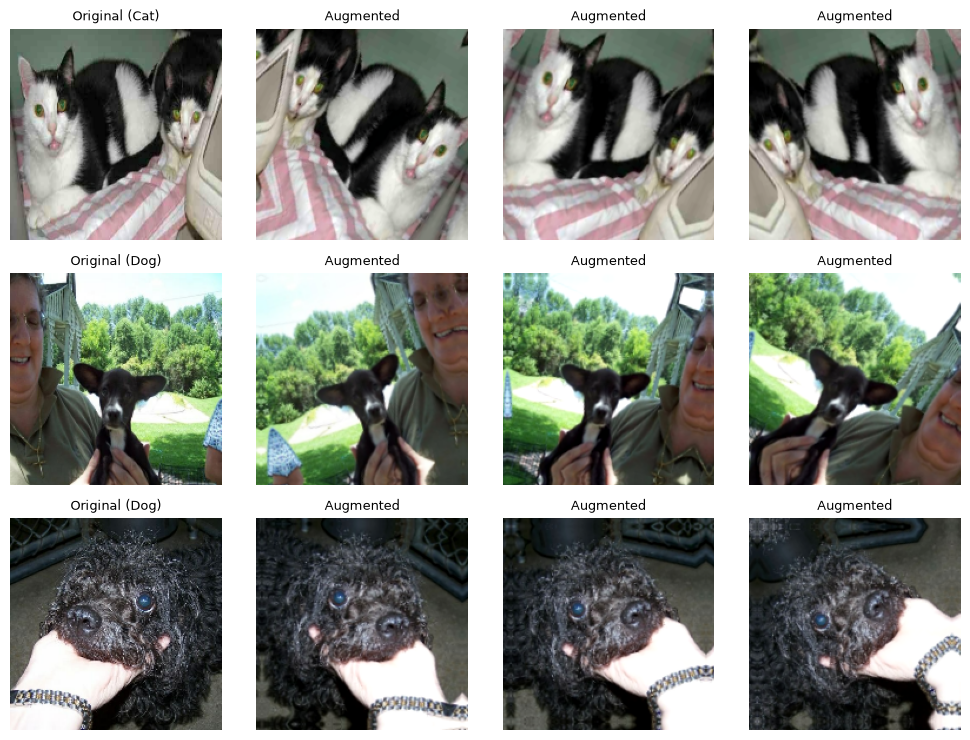

In [8]:
sample_images, sample_labels = next(iter(train_ds))
CLASS_NAMES = {0: "Cat", 1: "Dog"}

n_originals = 3
n_augmented_per_image = 3

plt.figure(figsize=(n_augmented_per_image * 2.5 + 2.5, n_originals * 2.5))
for row in range(n_originals):
    original = sample_images[row]

    plt.subplot(n_originals, n_augmented_per_image + 1, row * (n_augmented_per_image + 1) + 1)
    plt.imshow(original.numpy().astype("uint8"))
    plt.title(f"Original ({CLASS_NAMES[int(sample_labels[row].numpy())]})", fontsize=9)
    plt.axis("off")

    for col in range(n_augmented_per_image):
        augmented = data_augmentation(tf.expand_dims(original, 0), training=True)[0]
        plt.subplot(n_originals, n_augmented_per_image + 1, row * (n_augmented_per_image + 1) + col + 2)
        plt.imshow(tf.clip_by_value(augmented, 0, 255).numpy().astype("uint8"))
        plt.title("Augmented", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()


**What to check in the grid above:** every augmented image should still be clearly
recognizable as the same cat or dog — just flipped, slightly rotated, slightly zoomed, or with
slightly different contrast. If anything looks unrecognizable or semantically changed, the
augmentation ranges in Section 6 are too aggressive.


## Shared Experiment Helper

**What are we doing?** Writing one small function that compiles, trains, times, and evaluates a model the same way for every experiment below.

**Why are we doing it?** This is a *controlled* comparison — every experiment must be trained and measured identically so that any difference in results comes from the architecture change itself, not from an accidental inconsistency in the training code. Writing this once also avoids copy-pasting the same 20 lines five times.

**Best loss epoch vs. best accuracy epoch:** these are tracked **independently** — the epoch with the lowest `val_loss` is not necessarily the epoch with the highest `val_accuracy`. We report both, with their own epoch numbers, rather than assuming one implies the other.

**Precision/Recall/F1 come from the restored best-val-loss model.** Because `restore_best_weights=True` restores the weights from the best-`val_loss` epoch after training finishes, `model` at prediction time already reflects that epoch — so Precision/Recall/F1 below correspond to the best-val-loss checkpoint, not necessarily the best-val-accuracy epoch. This is a reasonable, consistent choice (matching what `ModelCheckpoint` also saves to disk), and we state it explicitly here rather than leaving it implicit.


In [9]:
def get_val_predictions(model, val_ds, threshold=0.5):
    """Run the model over the validation set once and return true labels + thresholded predictions.

    Because `restore_best_weights=True` has already restored the best-val-loss weights into
    `model` by the time this is called, these predictions -- and the Precision/Recall/F1
    computed from them -- correspond to that best-val-loss checkpoint.
    """
    y_true, y_prob = [], []
    for images, labels in val_ds:
        probs = model.predict(images, verbose=0).ravel()
        y_true.extend(labels.numpy())
        y_prob.extend(probs)
    y_true = np.array(y_true)
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return y_true, y_pred


def run_experiment(model, name, filename, notes=""):
    """Compile, train, time, and evaluate one experiment using the shared training policy.

    Best validation loss and best validation accuracy are tracked independently, since the
    epoch with the lowest val_loss is not necessarily the epoch with the highest val_accuracy
    (this was already observed in Notebook 03: best val_loss at epoch 3, best val_accuracy at
    epoch 5).
    """
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
    checkpoint = callbacks.ModelCheckpoint(filename, monitor="val_loss", save_best_only=True)

    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        shuffle=False,
        callbacks=[early_stopping, checkpoint],
    )
    training_time_seconds = time.time() - start_time

    # Best validation loss and its epoch
    best_loss_index = int(np.argmin(history.history["val_loss"]))
    best_val_loss = float(history.history["val_loss"][best_loss_index])
    best_val_loss_epoch = best_loss_index + 1

    # Best validation accuracy and its epoch -- tracked independently, not assumed to match
    best_acc_index = int(np.argmax(history.history["val_accuracy"]))
    best_val_acc = float(history.history["val_accuracy"][best_acc_index])
    best_val_acc_epoch = best_acc_index + 1

    # model currently holds the restored best-val-loss weights (restore_best_weights=True),
    # so these P/R/F1 values correspond to that same checkpoint.
    y_true, y_pred = get_val_predictions(model, val_ds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    result = {
        "Experiment": name,
        "Best Val Accuracy": round(best_val_acc, 4),
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Best Val Loss": round(best_val_loss, 4),
        "Best Val Loss Epoch": best_val_loss_epoch,
        "Val Precision": round(float(precision), 4),
        "Val Recall": round(float(recall), 4),
        "Val F1": round(float(f1), 4),
        "Training Time (min)": round(training_time_seconds / 60, 2),
        "Parameters": model.count_params(),
        "Notes": notes,
    }

    return history, result


histories = {}
results = [baseline_reference]


## 8. Experiment 1 — Data Augmentation

**What are we doing?** Same baseline architecture, with the `data_augmentation` block inserted
right after the input, before rescaling. Everything else (conv stack, dense head, training policy)
is identical to the baseline — augmentation is the only factor changing.


In [10]:
augmentation_model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="augmentation_cnn")

history_aug, result_aug = run_experiment(
    augmentation_model, "Data Augmentation", "augmentation_cnn.keras",
    notes="Baseline architecture + RandomFlip/Rotation/Zoom/Contrast",
)
histories["Data Augmentation"] = history_aug
results.append(result_aug)

# The augmentation layers add zero trainable parameters, so the baseline's parameter
# count (same conv/dense stack) is identical to this model's count.
baseline_reference["Parameters"] = augmentation_model.count_params()


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 477s 759ms/step - accuracy: 0.6106 - loss: 0.6586 - val_accuracy: 0.6672 - val_loss: 0.6103
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 577s 922ms/step - accuracy: 0.7175 - loss: 0.5557 - val_accuracy: 0.7617 - val_loss: 0.5083
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 654s 972ms/step - accuracy: 0.7503 - loss: 0.5077 - val_accuracy: 0.7677 - val_loss: 0.4829
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 559s 894ms/step - accuracy: 0.7699 - loss: 0.4794 - val_accuracy: 0.8122 - val_loss: 0.4102
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 593s 950ms/step - accuracy: 0.7899 - loss: 0.4458 - val_accuracy: 0.8010 - val_loss: 0.4158
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 432s 690ms/step - accuracy: 0.8062 - loss: 0.4198 - val_accuracy: 0.8214 - val_loss: 0.3770
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 361s 578ms/step - accuracy: 0.8158 - loss: 0.4006 - val_accuracy: 0.8146 - val_loss: 0.3951
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.8321 -

## 9. Experiment 2 — Batch Normalization

**What are we doing?** Same baseline architecture (no augmentation), with a `BatchNormalization`
layer added after each convolutional layer, before pooling.

**Why?** Batch Normalization re-centers and re-scales each layer's outputs during training, which
often makes training more stable and can also have a mild regularizing effect.


In [11]:
batchnorm_model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="batchnorm_cnn")

history_bn, result_bn = run_experiment(
    batchnorm_model, "Batch Normalization", "batchnorm_cnn.keras",
    notes="Baseline architecture + BatchNorm after each Conv2D",
)
histories["Batch Normalization"] = history_bn
results.append(result_bn)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 776s 1s/step - accuracy: 0.6409 - loss: 0.7767 - val_accuracy: 0.6904 - val_loss: 0.5671
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 820s 1s/step - accuracy: 0.7814 - loss: 0.4576 - val_accuracy: 0.6980 - val_loss: 0.5645
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1009s 2s/step - accuracy: 0.8231 - loss: 0.3921 - val_accuracy: 0.5483 - val_loss: 15.6528
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1009s 2s/step - accuracy: 0.8248 - loss: 0.4085 - val_accuracy: 0.8082 - val_loss: 0.4284
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.8749 - loss: 0.2849 - val_accuracy: 0.7829 - val_loss: 0.4652
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 524s 838ms/step - accuracy: 0.9083 - loss: 0.2142 - val_accuracy: 0.8086 - val_loss: 0.4460
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 534s 854ms/step - accuracy: 0.9283 - loss: 0.1645 - val_accuracy: 0.8082 - val_loss: 0.5592
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 659s 1s/step - accuracy: 0.9450 - loss: 0.1264 -

## 10. Experiment 3 — Dropout

**What are we doing?** Same baseline architecture (no augmentation), with a single `Dropout(0.5)`
layer added after `Flatten`, before the dense layer.

**Why?** Dropout randomly "turns off" a fraction of neurons during training, which discourages the
network from over-relying on specific neurons — a direct attempt to reduce the overfitting seen in
Notebook 03.


In [13]:
dropout_model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="dropout_cnn")

history_do, result_do = run_experiment(
    dropout_model, "Dropout", "dropout_cnn.keras",
    notes="Baseline architecture + Dropout(0.5) after Flatten",
)
histories["Dropout"] = history_do
results.append(result_do)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 601s 940ms/step - accuracy: 0.5999 - loss: 0.6649 - val_accuracy: 0.6480 - val_loss: 0.6329
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 557s 892ms/step - accuracy: 0.7368 - loss: 0.5291 - val_accuracy: 0.7709 - val_loss: 0.4836
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 488s 781ms/step - accuracy: 0.7891 - loss: 0.4474 - val_accuracy: 0.7950 - val_loss: 0.4349
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 402s 643ms/step - accuracy: 0.8217 - loss: 0.3923 - val_accuracy: 0.8070 - val_loss: 0.4137
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 231s 370ms/step - accuracy: 0.8521 - loss: 0.3394 - val_accuracy: 0.8158 - val_loss: 0.3962
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 239s 382ms/step - accuracy: 0.8817 - loss: 0.2811 - val_accuracy: 0.8354 - val_loss: 0.3762
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 420ms/step - accuracy: 0.9072 - loss: 0.2224 - val_accuracy: 0.8326 - val_loss: 0.3903
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 430ms/step - accuracy: 0.9314 -

## 11. Experiment 4 — Slightly Deeper CNN

**What are we doing?** Adding one modest fourth Conv2D+MaxPooling block (256 filters) on top of the
baseline's three blocks. No augmentation, no BatchNorm, no Dropout — depth is the only factor
changing here.

**Why only one extra block?** A CPU training budget doesn't support a large architecture search.
One additional block is enough to test whether a bit more representational capacity helps, without
a large jump in parameters or training time.


In [15]:
deeper_model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="deeper_cnn")

history_deep, result_deep = run_experiment(
    deeper_model, "Slightly Deeper CNN", "deeper_cnn.keras",
    notes="Baseline architecture + one extra Conv2D(256)+MaxPooling block",
)
histories["Slightly Deeper CNN"] = history_deep
results.append(result_deep)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 796ms/step - accuracy: 0.5855 - loss: 0.6629 - val_accuracy: 0.6456 - val_loss: 0.6347
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 595s 951ms/step - accuracy: 0.7291 - loss: 0.5370 - val_accuracy: 0.7809 - val_loss: 0.4542
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 704s 1s/step - accuracy: 0.8012 - loss: 0.4308 - val_accuracy: 0.8286 - val_loss: 0.3738
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.8469 - loss: 0.3492 - val_accuracy: 0.8206 - val_loss: 0.4115
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 583s 932ms/step - accuracy: 0.8774 - loss: 0.2887 - val_accuracy: 0.8738 - val_loss: 0.2994
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 685s 1s/step - accuracy: 0.9020 - loss: 0.2284 - val_accuracy: 0.8763 - val_loss: 0.3018
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 699s 1s/step - accuracy: 0.9327 - loss: 0.1675 - val_accuracy: 0.8779 - val_loss: 0.3081
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 383s 611ms/step - accuracy: 0.9539 - loss: 0.117

## 12. Experiment 5 — Combined Regularized CNN

**What are we doing?** Combining the techniques above into one deliberately-designed model:
augmentation, BatchNorm after each conv layer, Dropout before the dense layer, and the modest
fourth conv block.

**Why combine them at all?** Each experiment above isolates one factor. This experiment asks a
different question: do these techniques, applied together, produce a better result than any one of
them alone — or do they interfere with each other?


In [16]:
combined_model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="combined_cnn")

history_combined, result_combined = run_experiment(
    combined_model, "Combined Regularized CNN", "combined_cnn.keras",
    notes="Augmentation + BatchNorm + Dropout(0.5) + one extra Conv2D(256) block",
)
histories["Combined Regularized CNN"] = history_combined
results.append(result_combined)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 569s 903ms/step - accuracy: 0.6875 - loss: 0.6214 - val_accuracy: 0.7117 - val_loss: 0.5593
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 559s 894ms/step - accuracy: 0.7658 - loss: 0.4855 - val_accuracy: 0.7277 - val_loss: 0.5394
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 553s 885ms/step - accuracy: 0.8000 - loss: 0.4275 - val_accuracy: 0.8302 - val_loss: 0.3864
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 555s 889ms/step - accuracy: 0.8368 - loss: 0.3661 - val_accuracy: 0.8318 - val_loss: 0.3766
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 561s 898ms/step - accuracy: 0.8513 - loss: 0.3354 - val_accuracy: 0.8610 - val_loss: 0.3121
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1023s 2s/step - accuracy: 0.8719 - loss: 0.2968 - val_accuracy: 0.8763 - val_loss: 0.2879
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 967s 2s/step - accuracy: 0.8873 - loss: 0.2657 - val_accuracy: 0.8662 - val_loss: 0.2998
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1206s 2s/step - accuracy: 0.8983 - loss: 

## 13. Experiment Comparison

**What are we doing?** Collecting every experiment's results (plus the Notebook 03 baseline
reference) into one comparison table, sorted by validation accuracy.


In [17]:
results_df = pd.DataFrame(results)[
    ["Experiment", "Best Val Accuracy", "Best Val Accuracy Epoch", "Best Val Loss",
     "Best Val Loss Epoch", "Val Precision", "Val Recall", "Val F1",
     "Training Time (min)", "Parameters", "Notes"]
]
results_df = results_df.sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)
results_df


,Experiment,Best Val Accuracy,Best Val Accuracy Epoch,Best Val Loss,Best Val Loss Epoch,Val Precision,Val Recall,Val F1,Training Time (min),Parameters,Notes
0,Combined Regularized CNN,0.9155,14,0.2018,11,0.9184,0.9103,0.9144,207.43,3044801,Augmentation + BatchNorm + Dropout(0.5) + one ...
1,Slightly Deeper CNN,0.8903,12,0.2994,5,0.8637,0.8879,0.8756,111.28,3042881,Baseline architecture + one extra Conv2D(256) ...
2,Data Augmentation,0.8791,15,0.2673,15,0.8474,0.9247,0.8844,108.02,6647105,Baseline architecture + RandomFlip/Rotation/Zo...
3,Batch Normalization,0.8442,10,0.4284,4,0.8438,0.7566,0.7978,178.15,6648001,Baseline architecture + BatchNorm after each C...
4,Dropout,0.8354,6,0.3762,6,0.8141,0.8695,0.8409,90.12,6647105,Baseline architecture + Dropout(0.5) after Fla...
5,Baseline (Notebook 03),0.8230,6,0.3936,3,NaN,NaN,NaN,NaN,6647105,"Reference only, not retrained here. Strong ove..."


## 14. Training Curves

**What are we doing?** Plotting training vs validation accuracy and loss for each experiment
trained in this notebook (the baseline's curves already exist in Notebook 03, so they aren't
reproduced here).

**Why are we doing it?** The comparison table gives us final numbers, but the curves show
**how** each model got there — whether overfitting was reduced, delayed, or unaffected.


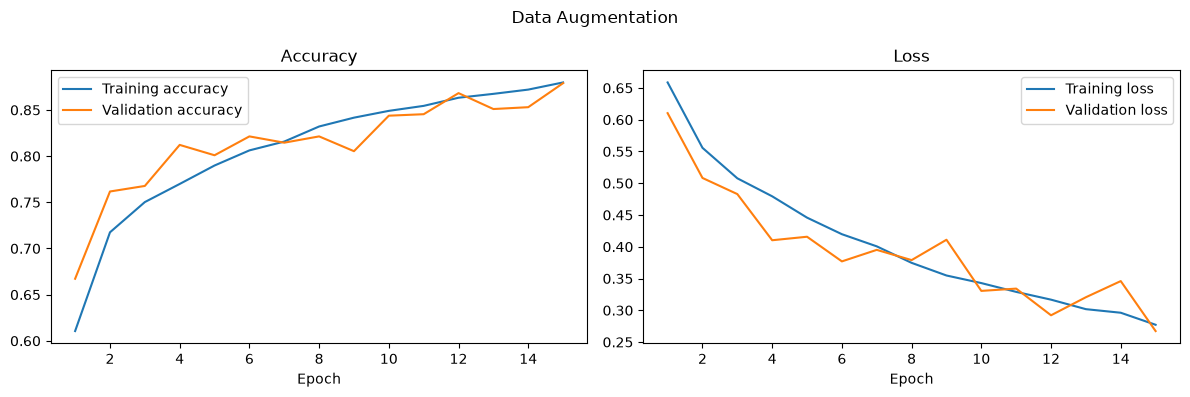

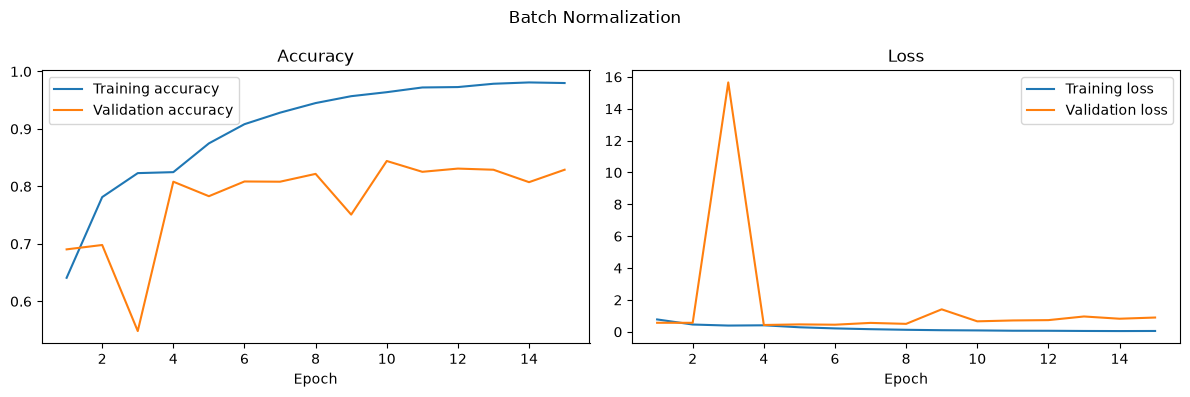

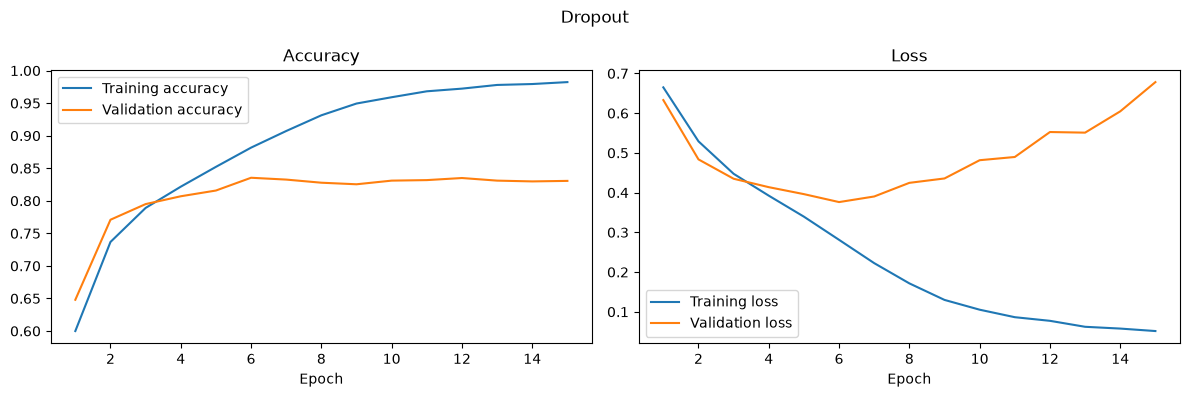

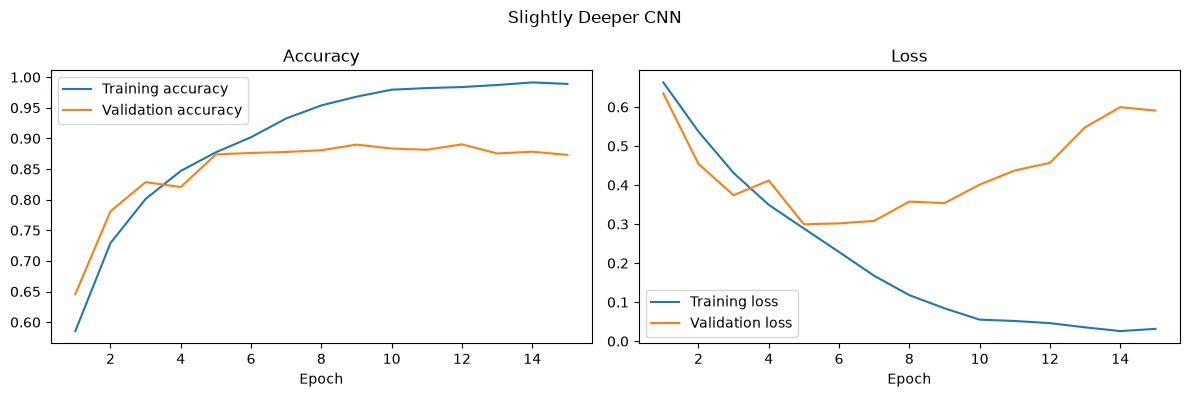

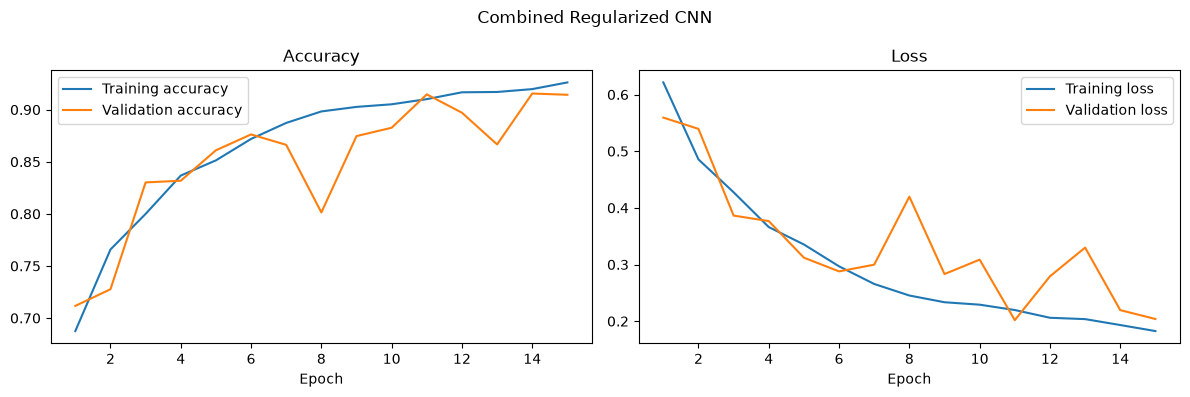

In [18]:
for name, history in histories.items():
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(name)

    axes[0].plot(epochs_range, acc, label="Training accuracy")
    axes[0].plot(epochs_range, val_acc, label="Validation accuracy")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_range, loss, label="Training loss")
    axes[1].plot(epochs_range, val_loss, label="Validation loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### Findings and Interpretation

The experiments demonstrate that the combined regularization strategy provided the strongest
overall improvement over the baseline CNN. The baseline achieved a best validation accuracy of
82.30%, while the Combined Regularized CNN reached 91.55% with a validation F1-score of 91.44%.
This improvement was accompanied by a substantial reduction in the model's parameter count, from
approximately 6.65 million in the baseline to 3.04 million in the combined model. The training
curves also show that the combined model maintained a very small gap between training and
validation performance at its best epoch, indicating substantially better generalization and much
less overfitting than the baseline. In contrast, Batch Normalization (84.42%) and Dropout (83.54%)
applied alone showed clearer divergence between training and validation performance as training
progressed and only modest gains over the baseline. The Slightly Deeper CNN (89.03%) and Data
Augmentation (87.91%) experiments each produced a stronger standalone improvement and helped
maintain a more stable relationship between training and validation performance, though neither
matched the combined model. Overall, the results support the use of the combined architecture as
the strongest from-scratch CNN configuration for the next stage of the project. However, these
experiments should be interpreted as controlled comparisons rather than a complete ablation study,
since the individual components were not evaluated across every possible combination. The selected
model will therefore serve as the from-scratch reference model for comparison with transfer
learning in Notebook 05.


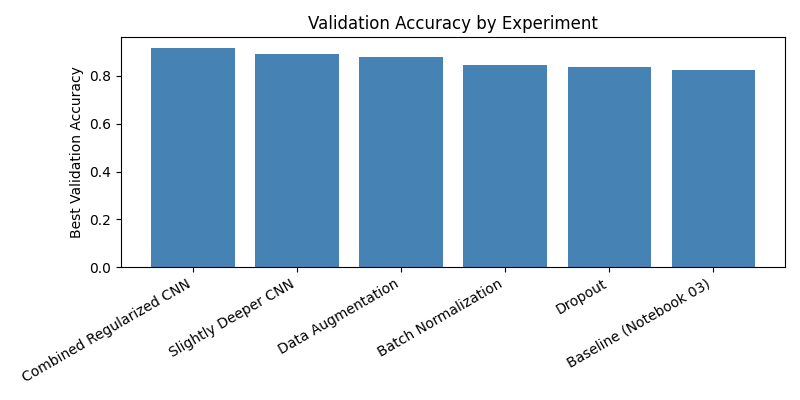

In [19]:
# Final comparison: validation accuracy across all experiments (including the baseline reference)
plt.figure(figsize=(8, 4))
plt.bar(results_df["Experiment"], results_df["Best Val Accuracy"], color="steelblue")
plt.ylabel("Best Validation Accuracy")
plt.xticks(rotation=30, ha="right")
plt.title("Validation Accuracy by Experiment")
plt.tight_layout()
plt.show()


## 15. Findings and Model Selection

**What are we doing?** Selecting the strongest from-scratch CNN to carry forward to Notebook 05.

**Selection criteria (in this order):** validation accuracy first, then F1, overfitting behavior
(gap between training and validation curves), parameter count, and training cost. We do **not**
pick a model just because it has the highest training accuracy, and the test set plays no role in
this decision.

Run the cell below once the table above is filled in, and read off the top row — then confirm by
eye against the training curves in Section 14 that the top-ranked model isn't simply the one that
overfit fastest.


In [20]:
best_row = results_df.iloc[0]
print("Top-ranked experiment by validation accuracy:")
print(best_row)


Top-ranked experiment by validation accuracy:
Experiment                                          Combined Regularized CNN
Best Val Accuracy                                                     0.9155
Best Val Accuracy Epoch                                                   14
Best Val Loss                                                         0.2018
Best Val Loss Epoch                                                       11
Val Precision                                                         0.9184
Val Recall                                                            0.9103
Val F1                                                                0.9144
Training Time (min)                                                   207.43
Parameters                                                           3044801
Notes                      Augmentation + BatchNorm + Dropout(0.5) + one ...
Name: 0, dtype: object


Based on the comparison table (Section 13) and training curves (Section 14), the Combined
Regularized CNN produced the strongest result among the five controlled experiments, reaching
91.55% validation accuracy and 91.44% F1 -- a clear improvement over the 82.30% baseline, and
stronger than every individual technique on its own (Slightly Deeper CNN 89.03%, Data Augmentation
87.91%, Batch Normalization 84.42%, Dropout 83.54%), with a notably smaller train/validation gap at
its best epoch than those individual experiments. Combining the techniques therefore outperformed
every individual technique rather than underperforming the best single one. The Combined
Regularized CNN (~3.04M parameters) is selected as `selected_model` and carried forward as the
from-scratch reference point for Notebook 05.


## 16. Conclusion

This notebook tested five controlled modifications to the Notebook 03 baseline CNN — data
augmentation, Batch Normalization, Dropout, a modestly deeper architecture, and a combination of
these — all trained on the identical train/validation split, with the test set left untouched
throughout.

The comparison table and training curves above identify which techniques actually improved
generalization on this dataset, rather than assuming any of them would help by default. The
selected best-performing from-scratch CNN will be used as the from-scratch reference point when
Notebook 05 evaluates transfer learning.
